[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-1/simple-graph.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58238187-lesson-2-simple-graph)

In [8]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph

In [2]:
import environment

## State

First, define the [State](https://langchain-ai.github.io/langgraph/concepts/low_level/#state) of the graph. 

The State schema serves as the input schema for all Nodes and Edges in the graph.

Let's use the `TypedDict` class from python's `typing` module as our schema, which provides type hints for the keys.

In [3]:

from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    isValid:bool
    intent:str
    response:str
    pass

In [4]:
state = MessagesState
print(state)

<class '__main__.MessagesState'>


In [5]:
import random
def input_validator(state):
    print("---input_validator---")
    if random.random() < 0.5:
        return {"isValid": False}
    return {"isValid": True}

def intent_extractor(state):
    print("---intent_extractor---")
    return {"intent": "greeting"}

def assistant(state):
    print("---assistant---")
    return {"messages":[]}

def format_response(state):
    print("---format_response---")
    return {"response": state['intent']}
 

In [47]:
import random
from typing import Any, Literal, Union
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

def validation_condition(state) -> Literal["__end__", "intent_extractor"]:
    isValid = state.get("isValid", False)
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if not isValid:
        # 50% of the time, we return Node 2
        return "__end__"
    else:
        return "intent_extractor"

from langchain_core.messages import (
    AIMessage,
    AnyMessage,
    ToolCall,
    ToolMessage,
)


def tools_condition(
    state: Union[list[AnyMessage], dict[str, Any], BaseModel],
) -> Literal["tools", "__end__"]:
    if isinstance(state, list):
        ai_message = state[-1]
    elif isinstance(state, dict) and (messages := state.get("messages", [])):
        ai_message = messages[-1]
    elif messages := getattr(state, "messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return "__end__"

In [48]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatOpenAI(model="gpt-4o")

# For this ipynb we set parallel tool calling to false as math generally is done sequentially, and this time we have 3 tools that can do math
# the OpenAI model specifically defaults to parallel tool calling for efficiency, see https://python.langchain.com/docs/how_to/tool_calling_parallel/
# play around with it and see how the model behaves with math equations!
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

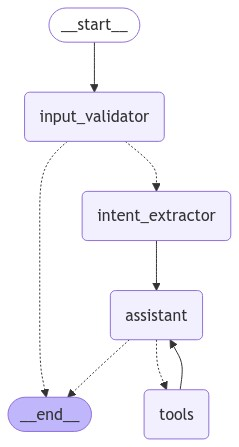

In [49]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import  ToolNode



# Build graph
builder = StateGraph(MessagesState)

builder.add_node("input_validator", input_validator)
builder.add_node("intent_extractor", intent_extractor)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode([add]))
# Logic
builder.add_edge(START, "input_validator")
builder.add_conditional_edges("input_validator", validation_condition)
builder.add_edge("intent_extractor", "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition,
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
)
builder.add_edge("tools", "assistant")

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

## Graph Invocation

The compiled graph implements the [runnable](https://python.langchain.com/v0.1/docs/expression_language/interface/) protocol.

This provides a standard way to execute LangChain components. 
 
`invoke` is one of the standard methods in this interface.

The input is a dictionary `{"graph_state": "Hi, this is lance."}`, which sets the initial value for our graph state dict.

When `invoke` is called, the graph starts execution from the `START` node.

It progresses through the defined nodes (`node_1`, `node_2`, `node_3`) in order.

The conditional edge will traverse from node `1` to node `2` or `3` using a 50/50 decision rule. 

Each node function receives the current state and returns a new value, which overrides the graph state.

The execution continues until it reaches the `END` node.

In [16]:
graph.invoke({"graph_state" : "Hi, this is ZOD."})

InvalidUpdateError: Must write to at least one of ['messages', 'isValid', 'intent', 'response']

`invoke` runs the entire graph synchronously.

This waits for each step to complete before moving to the next.

It returns the final state of the graph after all nodes have executed.

In this case, it returns the state after `node_3` has completed: 

```
{'graph_state': 'Hi, this is Lance. I am sad!'}
```